# Teacher + Pareto Dataset Analysis

Analysis of the generated teacher dataset after Beam Search, topology Pareto selection,
redispatch-aware selection, and final teacher replay.

The notebook expects the standard dataset layout:

```text
DATASET_DIR/
├── train/
│   ├── simple/examples.csv
│   ├── medium/examples.csv
│   └── hard/examples.csv
├── val/
│   ├── simple/examples.csv
│   ├── medium/examples.csv
│   └── hard/examples.csv
└── split_transitions/
    ├── transitions_train_simple.csv
    ├── transitions_train_medium.csv
    ├── transitions_train_hard.csv
    ├── transitions_val_simple.csv
    ├── transitions_val_medium.csv
    └── transitions_val_hard.csv
```

## 1. Dataset location

In [4]:
from pathlib import Path

DATASET_DIR = Path(r"D:/проекты/PowerGridReconfig/data/_scratch/case118_bootstrap_v1_test_teacher")

if DATASET_DIR.name.endswith("_teacher"):
    SOURCE_DATASET_DIR = DATASET_DIR.with_name(
        DATASET_DIR.name.removesuffix("_teacher")
    )
elif DATASET_DIR.name == "teacher":
    SOURCE_DATASET_DIR = DATASET_DIR.parent
else:
    raise ValueError(
        "Cannot infer the GridFM dataset directory from DATASET_DIR. "
        "Use either '<dataset>_teacher' or '<dataset>/teacher'."
    )


## 2. Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import json

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

splits = ["train", "val"]
classes = ["simple", "medium", "hard"]

## 3. Load all teacher examples and source transitions

In [7]:
example_frames = []
transition_frames = []

for split in splits:
    merged_examples_path = DATASET_DIR / f"examples_{split}.csv"

    if merged_examples_path.exists():
        examples_part = pd.read_csv(merged_examples_path)
        examples_part["split"] = split
        example_frames.append(examples_part)
    else:
        for difficulty in classes:
            examples_path = DATASET_DIR / split / difficulty / "examples.csv"
            examples_part = pd.read_csv(examples_path)
            examples_part["split"] = split
            examples_part["difficulty_class"] = difficulty
            example_frames.append(examples_part)

    transitions_path = (
        SOURCE_DATASET_DIR
        / "transitions"
        / f"transitions_{split}.csv"
    )
    transitions_part = pd.read_csv(transitions_path)
    transitions_part["split"] = split
    transition_frames.append(transitions_part)

examples = pd.concat(example_frames, ignore_index=True)
transitions = pd.concat(transition_frames, ignore_index=True)

# Current Teacher output keeps the public outcome separately from the
# diagnostic termination reason. Preserve the notebook's existing analysis
# column name without changing what downstream cells display.
if "termination_reason" not in examples.columns:
    examples["termination_reason"] = examples["diagnostic_termination_reason"]

# Compatibility aliases for the current Teacher provenance schema.
if "teacher_selected_safety" not in examples.columns:
    examples["teacher_selected_safety"] = examples["teacher_selected_J"]

# These historical diagnostics are no longer persisted by the current
# Teacher. Keep the columns so the existing tables/plots retain their shape
# without inventing replacement values.
for column in (
    "teacher_best_physical_safety",
    "teacher_retained_improvement_fraction",
    "teacher_pareto_front_size",
):
    if column not in examples.columns:
        examples[column] = np.nan

print(f"Teacher rows: {len(examples):,}")
print(f"Source scenarios: {transitions['scenario_id'].nunique():,}")


Teacher rows: 789
Source scenarios: 200


In [8]:
display(
    examples[
        [
            "split",
            "difficulty_class",
            "scenario_id",
            "step",
            "selected_action_id",
            "selected_branch_id",
            "termination_reason",
        ]
    ].head(10)
)

,split,difficulty_class,scenario_id,step,selected_action_id,selected_branch_id,termination_reason
0,train,simple,4,0,118,117.0,redispatch_validated
1,train,simple,4,1,96,95.0,redispatch_validated
2,train,simple,4,2,119,118.0,redispatch_validated
3,train,simple,4,3,141,140.0,redispatch_validated
4,train,simple,4,4,0,NaN,redispatch_validated
5,train,simple,5,0,174,173.0,redispatch_validated
6,train,simple,5,1,144,143.0,redispatch_validated
7,train,simple,5,2,67,66.0,redispatch_validated
8,train,simple,5,3,0,NaN,redispatch_validated
9,train,simple,7,0,155,154.0,redispatch_validated


## 4. Build one row per scenario

Teacher `examples.csv` contains one row per saved state.  
For dataset-level analysis we reduce it to one row per original GridFM scenario.

In [9]:
source_columns = [
    "scenario_id",
    "split",
    "difficulty_class",
    "max_loading_percent",
    "num_overloaded_branches",
    "num_hard_overloaded_branches",
    "seriousness_score",
]

source = (
    transitions[source_columns]
    .drop_duplicates(["split", "difficulty_class", "scenario_id"])
)

episode = (
    examples
    .sort_values(["split", "difficulty_class", "scenario_id", "step"])
    .groupby(
        ["split", "difficulty_class", "scenario_id"],
        as_index=False,
    )
    .agg(
        saved_examples=("step", "size"),
        final_return=("final_return", "first"),
        solved=("solved", "first"),
        termination_reason=("termination_reason", "first"),

        teacher_best_J=("teacher_best_physical_safety", "first"),
        teacher_selected_J=("teacher_selected_safety", "first"),
        teacher_selected_switches=("teacher_selected_switch_count", "first"),
        retained_improvement=("teacher_retained_improvement_fraction", "first"),

        topology_pareto_size=("teacher_pareto_front_size", "first"),

        terminal_selection_applied=("teacher_terminal_selection_applied", "first"),
        terminal_candidate_count=("teacher_terminal_candidate_count", "first"),
        redispatch_pareto_size=("teacher_terminal_pareto_front_size", "first"),

        redispatch_attempted=("redispatch_attempted", "first"),
        redispatch_validated=("redispatch_validated", "first"),
        redispatch_l1_mw=("redispatch_l1_mw", "first"),
        redispatch_up_mw=("redispatch_up_mw", "first"),
        redispatch_down_mw=("redispatch_down_mw", "first"),
        redispatch_max_generator_delta_mw=("redispatch_max_generator_delta_mw", "first"),
    )
)

action_summary = (
    examples
    .sort_values(["split", "difficulty_class", "scenario_id", "step"])
    .groupby(["split", "difficulty_class", "scenario_id"])
    .apply(
        lambda g: pd.Series({
            "physical_switches": int(g["selected_branch_id"].notna().sum()),
            "stop_actions": int((g["selected_action_id"] == 0).sum()),
            "sequence": " → ".join(
                "STOP" if pd.isna(branch_id) else str(int(branch_id))
                for branch_id in g["selected_branch_id"]
            ),
        }),
        include_groups=False,
    )
    .reset_index()
)

scenario = (
    source
    .merge(
        episode,
        on=["split", "difficulty_class", "scenario_id"],
        how="inner",
    )
    .merge(
        action_summary,
        on=["split", "difficulty_class", "scenario_id"],
        how="left",
    )
)

scenario["initial_J"] = scenario["teacher_selected_J"] + scenario["final_return"]
scenario["J_improvement"] = scenario["initial_J"] - scenario["teacher_selected_J"]
scenario["best_J_improvement"] = scenario["initial_J"] - scenario["teacher_best_J"]
scenario["J_gap_to_best"] = scenario["teacher_selected_J"] - scenario["teacher_best_J"]
scenario["J_improvement_percent"] = (
    100.0 * scenario["J_improvement"] / scenario["initial_J"]
)
scenario["retained_improvement_percent"] = 100.0 * scenario["retained_improvement"]
scenario["zero_switch"] = scenario["physical_switches"] == 0
scenario["has_stop"] = scenario["stop_actions"] > 0

display(scenario.head())

,scenario_id,split,difficulty_class,max_loading_percent,num_overloaded_branches,num_hard_overloaded_branches,seriousness_score,saved_examples,final_return,solved,...,stop_actions,sequence,initial_J,J_improvement,best_J_improvement,J_gap_to_best,J_improvement_percent,retained_improvement_percent,zero_switch,has_stop
0,4,train,simple,119.756361,2,0,1018.812243,5,59.839175,False,...,1,117 → 95 → 118 → 140 → STOP,65.131148,59.839175,NaN,NaN,91.874897,NaN,False,True
1,5,train,simple,118.604912,2,0,1013.024560,4,20.764206,False,...,1,173 → 143 → 66 → STOP,62.309122,20.764206,NaN,NaN,33.324504,NaN,False,True
2,7,train,simple,119.620657,1,0,818.103285,2,49.241318,False,...,1,154 → STOP,53.241326,49.241318,NaN,NaN,92.487024,NaN,False,True
3,9,train,simple,118.571792,2,0,1012.858962,3,34.866608,False,...,1,154 → 120 → STOP,61.669530,34.866608,NaN,NaN,56.537820,NaN,False,True
4,17,train,simple,119.248734,2,0,1016.243672,3,38.427155,False,...,1,149 → 155 → STOP,60.039460,38.427155,NaN,NaN,64.003165,NaN,False,True


## 5. Dataset composition

difficulty_class,simple,medium,hard
split,,,
train,25,50,25
val,25,50,25


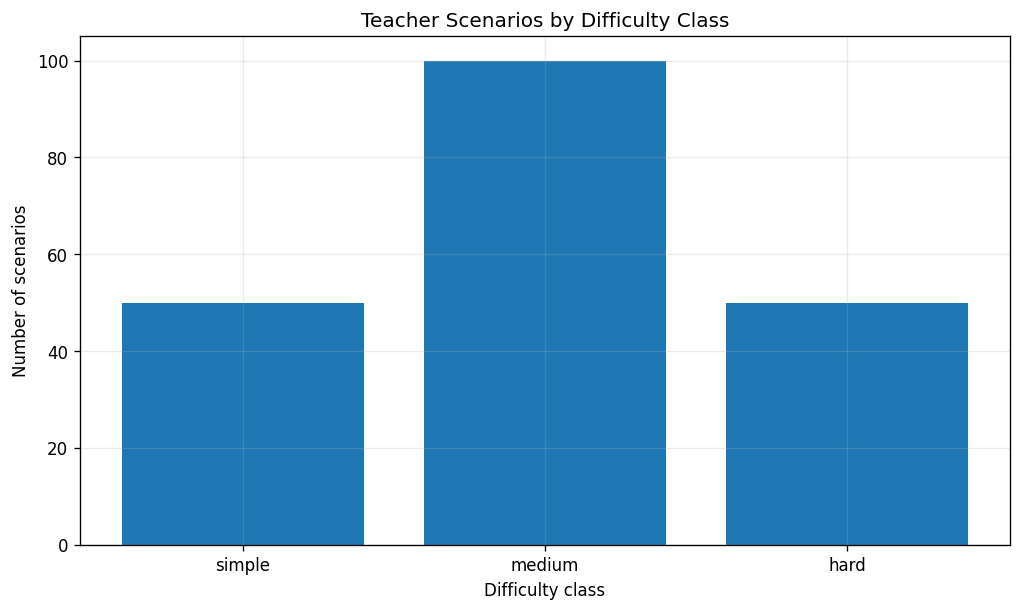

In [10]:
composition = (
    scenario
    .groupby(["split", "difficulty_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=splits, columns=classes)
)

display(composition)

total_by_class = composition.sum(axis=0)

fig, ax = plt.subplots()
ax.bar(total_by_class.index, total_by_class.values)
ax.set_title("Teacher Scenarios by Difficulty Class")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Number of scenarios")
plt.show()

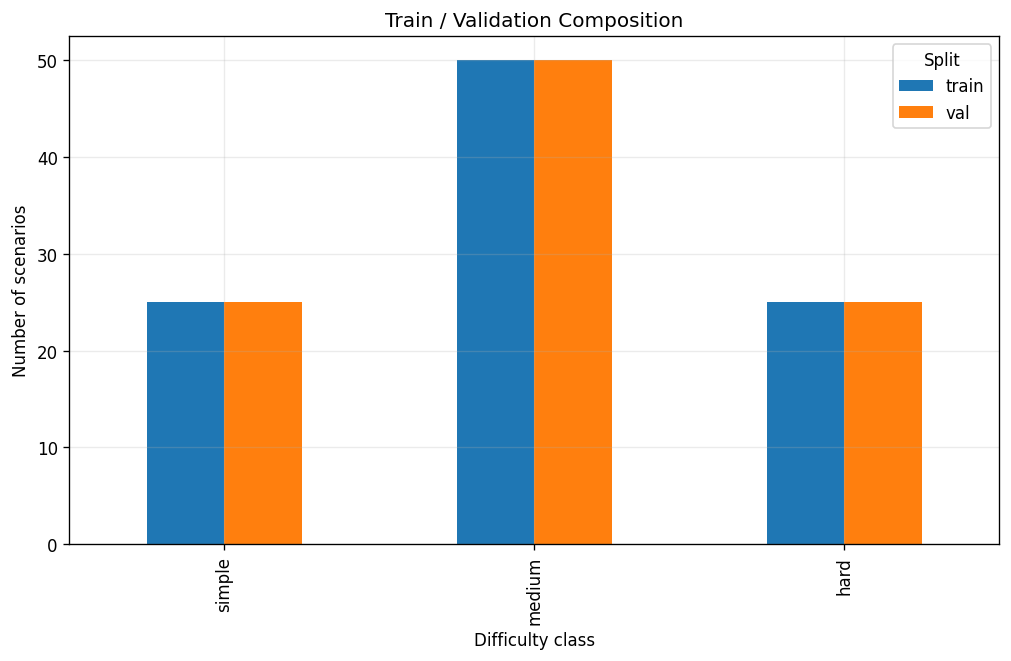

In [11]:
split_composition = composition.copy()

fig, ax = plt.subplots()
split_composition.T.plot(kind="bar", ax=ax)
ax.set_title("Train / Validation Composition")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Number of scenarios")
ax.legend(title="Split")
plt.show()

## 6. Overall and per-class summary

In [12]:
def summarize(df):
    validated_R = df.loc[
        df["redispatch_validated"].fillna(False),
        "redispatch_l1_mw",
    ]

    return pd.Series({
        "Scenarios": len(df),
        "Saved examples": df["saved_examples"].sum(),

        "Mean switches": df["physical_switches"].mean(),
        "Median switches": df["physical_switches"].median(),
        "Zero-switch, %": 100.0 * df["zero_switch"].mean(),
        "STOP / handoff, %": 100.0 * df["has_stop"].mean(),
        "Solved, %": 100.0 * df["solved"].mean(),

        "Mean initial J": df["initial_J"].mean(),
        "Mean best J": df["teacher_best_J"].mean(),
        "Mean final J": df["teacher_selected_J"].mean(),
        "Mean J improvement": df["J_improvement"].mean(),
        "Mean J improvement, %": df["J_improvement_percent"].mean(),
        "Mean retained improvement, %": df["retained_improvement_percent"].mean(),

        "Mean topology Pareto size": df["topology_pareto_size"].mean(),
        "Mean terminal candidates": df["terminal_candidate_count"].mean(),
        "Mean redispatch Pareto size": df["redispatch_pareto_size"].mean(),
        "Redispatch selection applied, %":
            100.0 * df["terminal_selection_applied"].mean(),

        "Redispatch validated, %":
            100.0 * df["redispatch_validated"].fillna(False).mean(),
        "Median validated redispatch, MW": validated_R.median(),
        "Mean validated redispatch, MW": validated_R.mean(),
    })

summary = pd.concat(
    [
        summarize(scenario).rename("overall"),
        *[
            summarize(
                scenario[scenario["difficulty_class"] == difficulty]
            ).rename(difficulty)
            for difficulty in classes
        ],
    ],
    axis=1,
).T

display(summary.round(3))

,Scenarios,Saved examples,Mean switches,Median switches,"Zero-switch, %","STOP / handoff, %","Solved, %",Mean initial J,Mean best J,Mean final J,Mean J improvement,"Mean J improvement, %","Mean retained improvement, %",Mean topology Pareto size,Mean terminal candidates,Mean redispatch Pareto size,"Redispatch selection applied, %","Redispatch validated, %","Median validated redispatch, MW","Mean validated redispatch, MW"
overall,200.0,789.0,2.995,3.0,4.0,95.0,0.0,490.617,NaN,386.846,103.771,50.434,NaN,NaN,23.305,3.795,95.0,95.0,82.862,204.138
simple,50.0,142.0,1.840,2.0,0.0,100.0,0.0,60.741,NaN,15.591,45.150,75.240,NaN,NaN,21.840,3.740,100.0,100.0,0.115,9.023
medium,100.0,450.0,3.500,4.0,5.0,100.0,0.0,249.085,NaN,114.814,134.272,57.098,NaN,NaN,25.240,4.520,100.0,100.0,88.803,118.712
hard,50.0,197.0,3.140,2.5,6.0,80.0,0.0,1403.556,NaN,1302.165,101.391,12.300,NaN,NaN,20.900,2.400,80.0,80.0,604.465,661.596


## 7. Train vs validation summary

In [13]:
split_summary = pd.concat(
    [
        summarize(scenario[scenario["split"] == split]).rename(split)
        for split in splits
    ],
    axis=1,
).T

display(split_summary.round(3))

,Scenarios,Saved examples,Mean switches,Median switches,"Zero-switch, %","STOP / handoff, %","Solved, %",Mean initial J,Mean best J,Mean final J,Mean J improvement,"Mean J improvement, %","Mean retained improvement, %",Mean topology Pareto size,Mean terminal candidates,Mean redispatch Pareto size,"Redispatch selection applied, %","Redispatch validated, %","Median validated redispatch, MW","Mean validated redispatch, MW"
train,100.0,387.0,2.89,2.5,2.0,98.0,0.0,541.429,NaN,442.714,98.715,49.808,NaN,NaN,24.65,3.95,98.0,98.0,91.177,227.683
val,100.0,402.0,3.10,3.0,6.0,92.0,0.0,439.805,NaN,330.978,108.827,51.061,NaN,NaN,21.96,3.64,92.0,92.0,56.388,179.057


## 8. Initial physical severity by class

In [14]:
initial_physics = (
    scenario
    .groupby("difficulty_class")
    .agg(
        scenarios=("scenario_id", "count"),
        mean_max_loading=("max_loading_percent", "mean"),
        median_max_loading=("max_loading_percent", "median"),
        mean_overloaded=("num_overloaded_branches", "mean"),
        mean_hard_overloaded=("num_hard_overloaded_branches", "mean"),
        mean_seriousness=("seriousness_score", "mean"),
        mean_initial_J=("initial_J", "mean"),
    )
    .reindex(classes)
)

display(initial_physics)

,scenarios,mean_max_loading,median_max_loading,mean_overloaded,mean_hard_overloaded,mean_seriousness,mean_initial_J
difficulty_class,,,,,,,
simple,50,119.076586,119.004456,1.48,0.00,911.615812,60.740757
medium,100,135.546839,135.766014,3.56,1.00,3410.512084,249.085435
hard,50,189.880266,186.062357,6.16,3.38,8965.728292,1403.556037


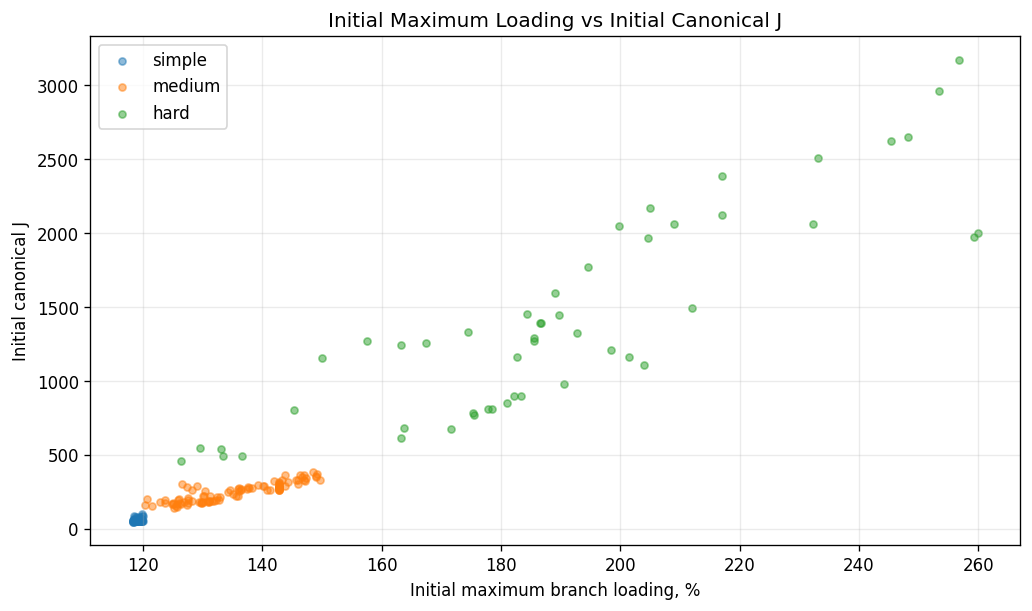

In [15]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = scenario[scenario["difficulty_class"] == difficulty]
    ax.scatter(
        data["max_loading_percent"],
        data["initial_J"],
        s=18,
        alpha=0.5,
        label=difficulty,
    )

ax.set_title("Initial Maximum Loading vs Initial Canonical J")
ax.set_xlabel("Initial maximum branch loading, %")
ax.set_ylabel("Initial canonical J")
ax.legend()
plt.show()

## 9. Physical switching actions

In [16]:
switch_stats = (
    scenario
    .groupby("difficulty_class")["physical_switches"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(switch_stats)

,count,mean,std,min,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,
simple,50.0,1.84,0.841767,1.0,1.0,2.0,2.00,3.55,4.0
medium,100.0,3.50,1.617455,0.0,2.0,4.0,5.00,5.00,5.0
hard,50.0,3.14,2.166630,0.0,1.0,2.5,5.75,6.00,6.0


physical_switches,0,1,2,3,4,5,6
difficulty_class,,,,,,,
simple,0,19,23,5,3,0,0
medium,5,12,9,18,14,42,0
hard,3,14,8,4,3,5,13


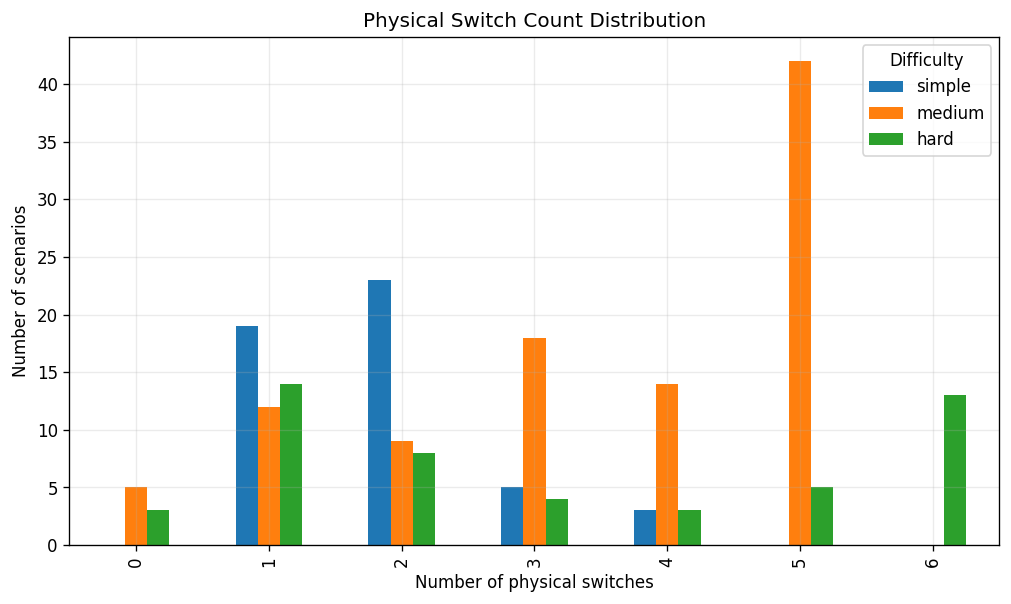

In [17]:
switch_distribution = (
    scenario
    .groupby(["difficulty_class", "physical_switches"])
    .size()
    .unstack(fill_value=0)
    .reindex(classes)
)

display(switch_distribution)

fig, ax = plt.subplots()
switch_distribution.T.plot(kind="bar", ax=ax)
ax.set_title("Physical Switch Count Distribution")
ax.set_xlabel("Number of physical switches")
ax.set_ylabel("Number of scenarios")
ax.legend(title="Difficulty")
plt.show()

## 10. Teacher trajectory length

In [18]:
length_stats = (
    scenario
    .groupby("difficulty_class")["saved_examples"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(length_stats)

,count,mean,std,min,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,
simple,50.0,2.84,0.841767,2.0,2.0,3.0,3.0,4.55,5.0
medium,100.0,4.50,1.617455,1.0,3.0,5.0,6.0,6.00,6.0
hard,50.0,3.94,1.920990,1.0,2.0,3.5,6.0,6.55,7.0


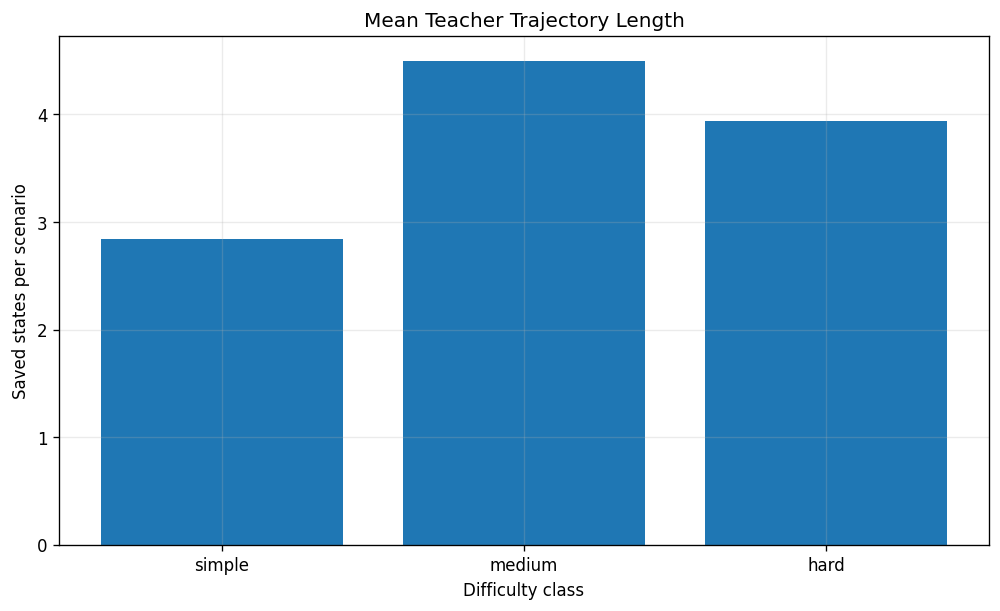

In [19]:
mean_length = (
    scenario
    .groupby("difficulty_class")["saved_examples"]
    .mean()
    .reindex(classes)
)

fig, ax = plt.subplots()
ax.bar(mean_length.index, mean_length.values)
ax.set_title("Mean Teacher Trajectory Length")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Saved states per scenario")
plt.show()

## 11. Termination outcomes

In [20]:
termination_table = (
    scenario
    .groupby(["difficulty_class", "termination_reason"])
    .size()
    .unstack(fill_value=0)
    .reindex(classes)
)

display(termination_table)

termination_reason,max_steps_reached,redispatch_validated
difficulty_class,,
simple,0,50
medium,0,100
hard,10,40


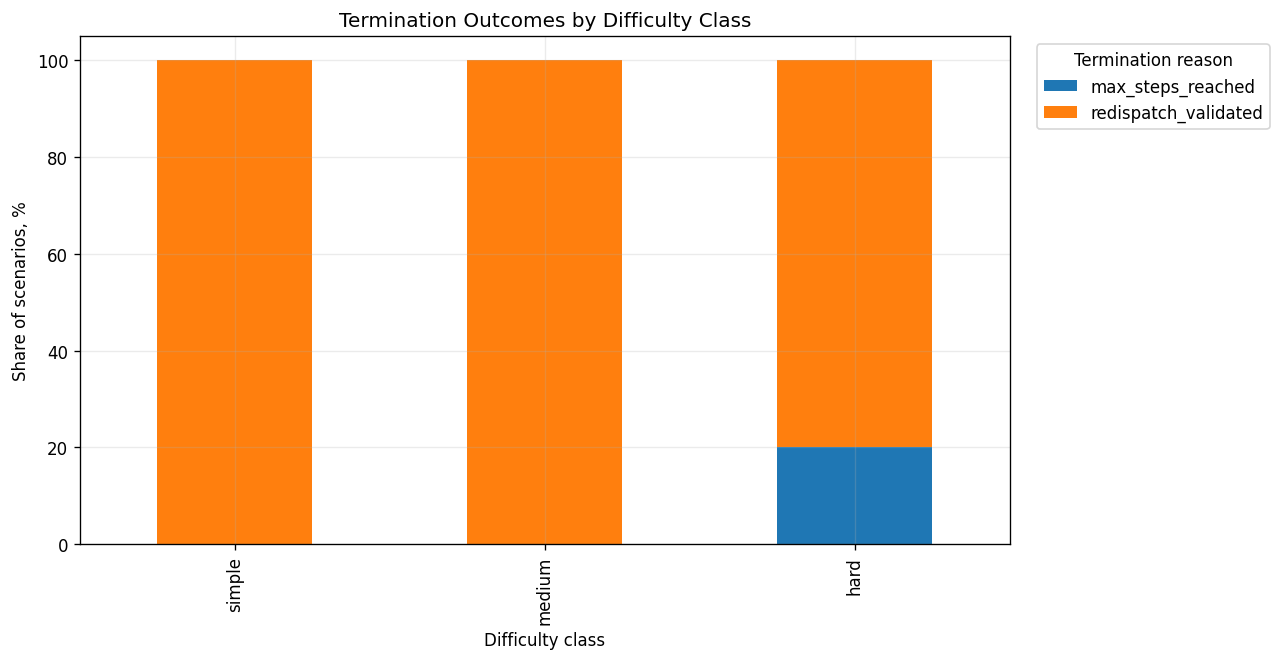

In [21]:
termination_percent = (
    100.0
    * termination_table.div(termination_table.sum(axis=1), axis=0)
)

fig, ax = plt.subplots()
termination_percent.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Termination Outcomes by Difficulty Class")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Share of scenarios, %")
ax.legend(title="Termination reason", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 12. Topology Pareto front size

In [22]:
topology_pareto_stats = (
    scenario
    .groupby("difficulty_class")["topology_pareto_size"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(topology_pareto_stats)

,count,mean,std,min,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,
simple,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medium,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hard,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


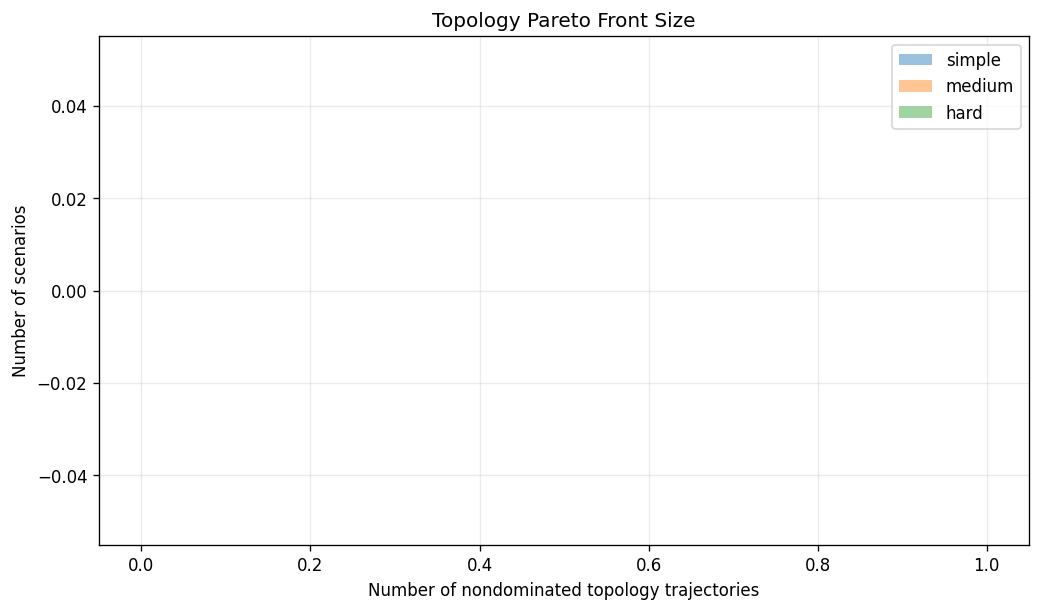

In [23]:
fig, ax = plt.subplots()

for difficulty in classes:
    values = scenario.loc[
        scenario["difficulty_class"] == difficulty,
        "topology_pareto_size",
    ].dropna()
    ax.hist(values, bins=30, alpha=0.45, label=difficulty)

ax.set_title("Topology Pareto Front Size")
ax.set_xlabel("Number of nondominated topology trajectories")
ax.set_ylabel("Number of scenarios")
ax.legend()
plt.show()

## 13. Best topology J vs final selected J

`teacher_best_J` is the best physical penalty found on the topology Pareto front.

`teacher_selected_J` is the J of the trajectory finally selected by the complete teacher pipeline,
including redispatch-aware selection when it is applicable.

In [24]:
J_selection = (
    scenario
    .groupby("difficulty_class")
    .agg(
        mean_initial_J=("initial_J", "mean"),
        mean_best_J=("teacher_best_J", "mean"),
        mean_selected_J=("teacher_selected_J", "mean"),
        mean_gap_to_best=("J_gap_to_best", "mean"),
        median_gap_to_best=("J_gap_to_best", "median"),
        p95_gap_to_best=("J_gap_to_best", lambda s: s.quantile(0.95)),
    )
    .reindex(classes)
)

display(J_selection)

,mean_initial_J,mean_best_J,mean_selected_J,mean_gap_to_best,median_gap_to_best,p95_gap_to_best
difficulty_class,,,,,,
simple,60.740757,NaN,15.590710,NaN,NaN,NaN
medium,249.085435,NaN,114.813703,NaN,NaN,NaN
hard,1403.556037,NaN,1302.164621,NaN,NaN,NaN


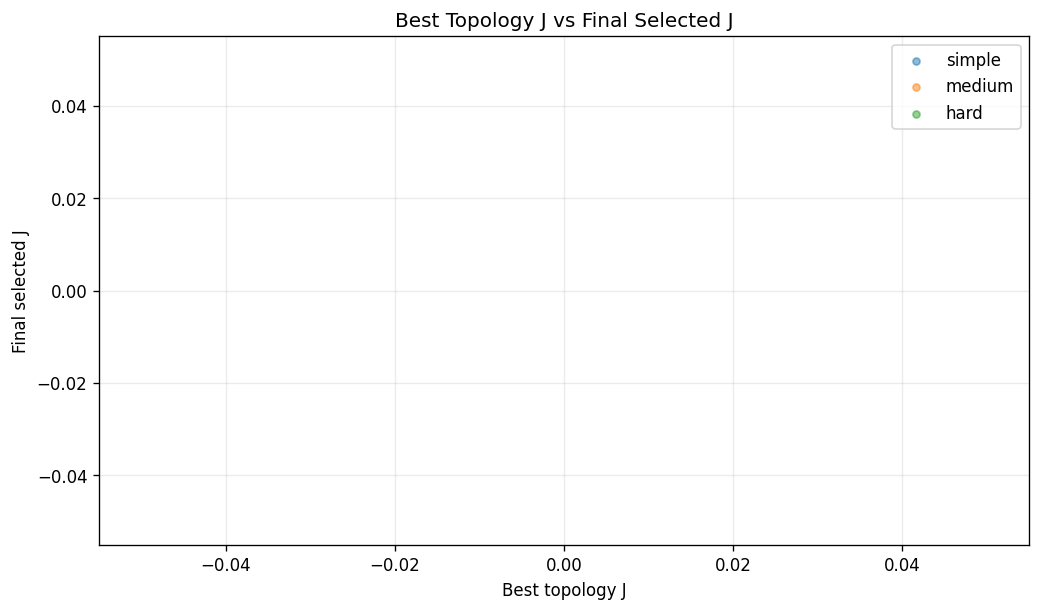

In [26]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = scenario[scenario["difficulty_class"] == difficulty]
    ax.scatter(
        data["teacher_best_J"],
        data["teacher_selected_J"],
        s=18,
        alpha=0.5,
        label=difficulty,
    )

max_J = max(
    scenario["teacher_best_J"].max(),
    scenario["teacher_selected_J"].max(),
)

ax.plot([0, max_J], [0, max_J], linestyle="--")
ax.set_title("Best Topology J vs Final Selected J")
ax.set_xlabel("Best topology J")
ax.set_ylabel("Final selected J")
ax.legend()
plt.show()

## 14. J improvement

In [27]:
improvement_stats = (
    scenario
    .groupby("difficulty_class")
    .agg(
        mean_J_improvement=("J_improvement", "mean"),
        median_J_improvement=("J_improvement", "median"),
        p95_J_improvement=("J_improvement", lambda s: s.quantile(0.95)),
        mean_J_improvement_percent=("J_improvement_percent", "mean"),
        median_J_improvement_percent=("J_improvement_percent", "median"),
    )
    .reindex(classes)
)

display(improvement_stats)

,mean_J_improvement,median_J_improvement,p95_J_improvement,mean_J_improvement_percent,median_J_improvement_percent
difficulty_class,,,,,
simple,45.150047,47.714005,61.767724,75.240464,77.120184
medium,134.271732,152.120461,237.554521,57.098181,67.784249
hard,101.391416,67.967194,353.969162,12.299825,5.155086


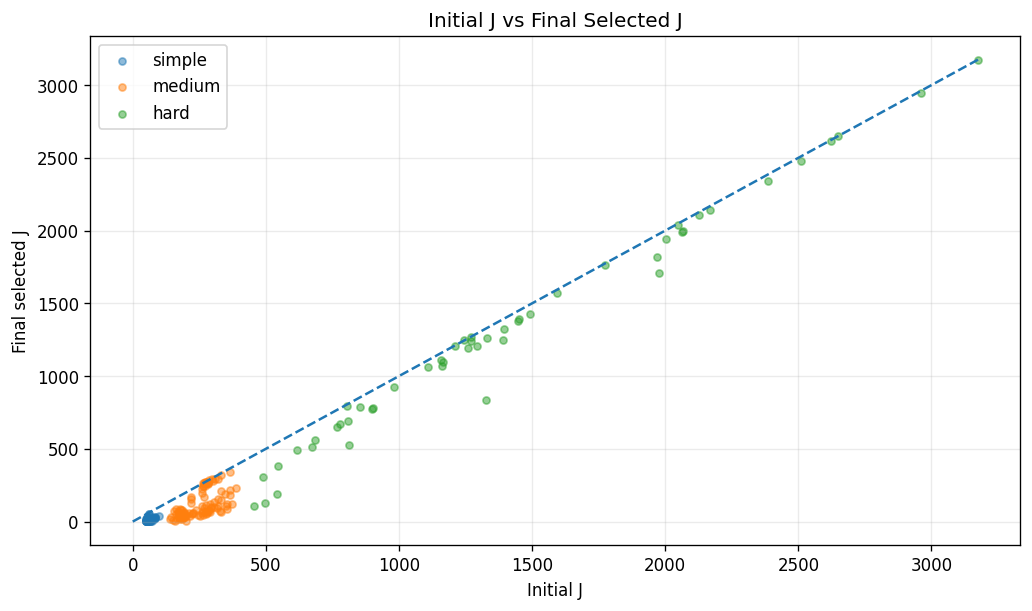

In [28]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = scenario[scenario["difficulty_class"] == difficulty]
    ax.scatter(
        data["initial_J"],
        data["teacher_selected_J"],
        s=18,
        alpha=0.5,
        label=difficulty,
    )

max_J = max(
    scenario["initial_J"].max(),
    scenario["teacher_selected_J"].max(),
)

ax.plot([0, max_J], [0, max_J], linestyle="--")
ax.set_title("Initial J vs Final Selected J")
ax.set_xlabel("Initial J")
ax.set_ylabel("Final selected J")
ax.legend()
plt.show()

In [29]:
final_loading_rows = []

first_states = (
    examples
    .sort_values(["split", "difficulty_class", "scenario_id", "step"])
    .groupby(["split", "difficulty_class", "scenario_id"], as_index=False)
    .first()
)

for _, row in first_states.iterrows():
    state_path = (
        DATASET_DIR
        / row["split"]
        / row["difficulty_class"]
        / "states"
        / Path(row["state_path"]).name
    )

    with np.load(state_path, allow_pickle=False) as data:
        metadata = json.loads(str(data["metadata_json"].item()))

    final_loading_rows.append({
        "split": row["split"],
        "difficulty_class": row["difficulty_class"],
        "scenario_id": row["scenario_id"],
        "final_max_loading_percent": metadata["replay_final_max_loading_percent"],
    })

final_loading = pd.DataFrame(final_loading_rows)

scenario = scenario.merge(
    final_loading,
    on=["split", "difficulty_class", "scenario_id"],
    how="left",
)

scenario["initial_max_overload_percent"] = np.maximum(
    scenario["max_loading_percent"] - 100.0,
    0.0,
)

scenario["final_max_overload_percent"] = np.maximum(
    scenario["final_max_loading_percent"] - 100.0,
    0.0,
)

scenario["max_loading_reduction"] = (
    scenario["max_loading_percent"]
    - scenario["final_max_loading_percent"]
)

In [30]:
overall_loading = pd.DataFrame(
    {
        "initial_mean": [scenario["max_loading_percent"].mean()],
        "initial_median": [scenario["max_loading_percent"].median()],
        "initial_max": [scenario["max_loading_percent"].max()],
        "final_mean": [scenario["final_max_loading_percent"].mean()],
        "final_median": [scenario["final_max_loading_percent"].median()],
        "final_max": [scenario["final_max_loading_percent"].max()],
        "mean_reduction": [scenario["max_loading_reduction"].mean()],
    },
    index=["overall"],
)

class_loading = (
    scenario
    .groupby("difficulty_class")
    .agg(
        initial_mean=("max_loading_percent", "mean"),
        initial_median=("max_loading_percent", "median"),
        initial_max=("max_loading_percent", "max"),
        final_mean=("final_max_loading_percent", "mean"),
        final_median=("final_max_loading_percent", "median"),
        final_max=("final_max_loading_percent", "max"),
        mean_reduction=("max_loading_reduction", "mean"),
    )
    .reindex(classes)
)

loading_summary = pd.concat(
    [
        overall_loading,
        class_loading,
    ]
)

display(loading_summary.round(2))

,initial_mean,initial_median,initial_max,final_mean,final_median,final_max,mean_reduction
overall,145.01,133.78,259.96,129.57,113.26,256.77,15.45
simple,119.08,119.00,120.00,101.51,100.26,118.24,17.56
medium,135.55,135.77,149.67,117.35,113.21,146.79,18.20
hard,189.88,186.06,259.96,182.06,179.02,256.77,7.82


,Before,After
difficulty_class,,
simple,119.08,101.51
medium,135.55,117.35
hard,189.88,182.06


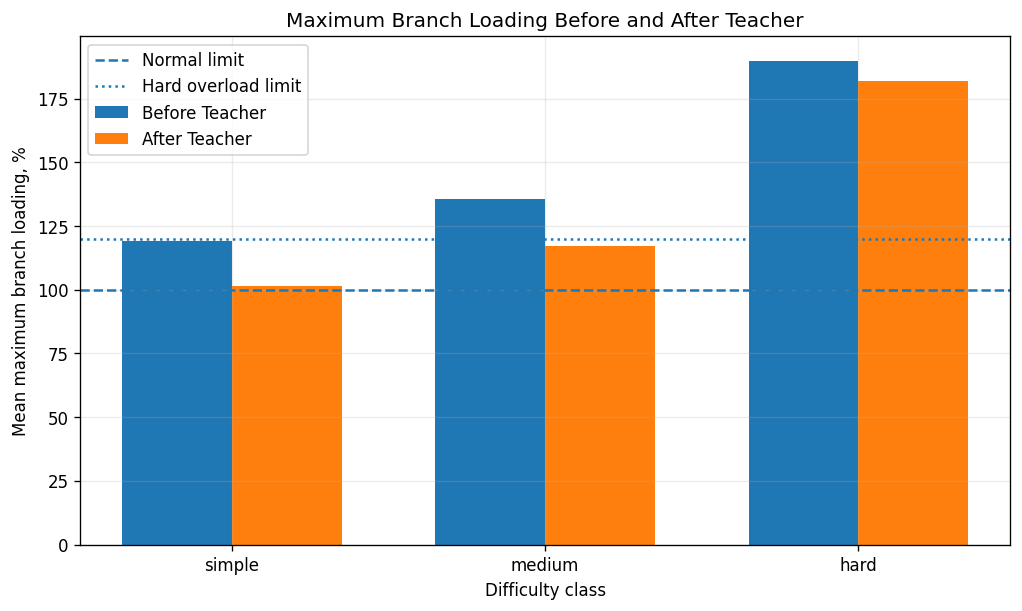

In [31]:
comparison = (
    scenario
    .groupby("difficulty_class")
    .agg(
        Before=("max_loading_percent", "mean"),
        After=("final_max_loading_percent", "mean"),
    )
    .reindex(classes)
)

display(comparison.round(2))

fig, ax = plt.subplots()

x = np.arange(len(classes))
width = 0.35

ax.bar(
    x - width / 2,
    comparison["Before"],
    width,
    label="Before Teacher",
)

ax.bar(
    x + width / 2,
    comparison["After"],
    width,
    label="After Teacher",
)

ax.axhline(100, linestyle="--", label="Normal limit")
ax.axhline(120, linestyle=":", label="Hard overload limit")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_title("Maximum Branch Loading Before and After Teacher")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Mean maximum branch loading, %")
ax.legend()

plt.show()

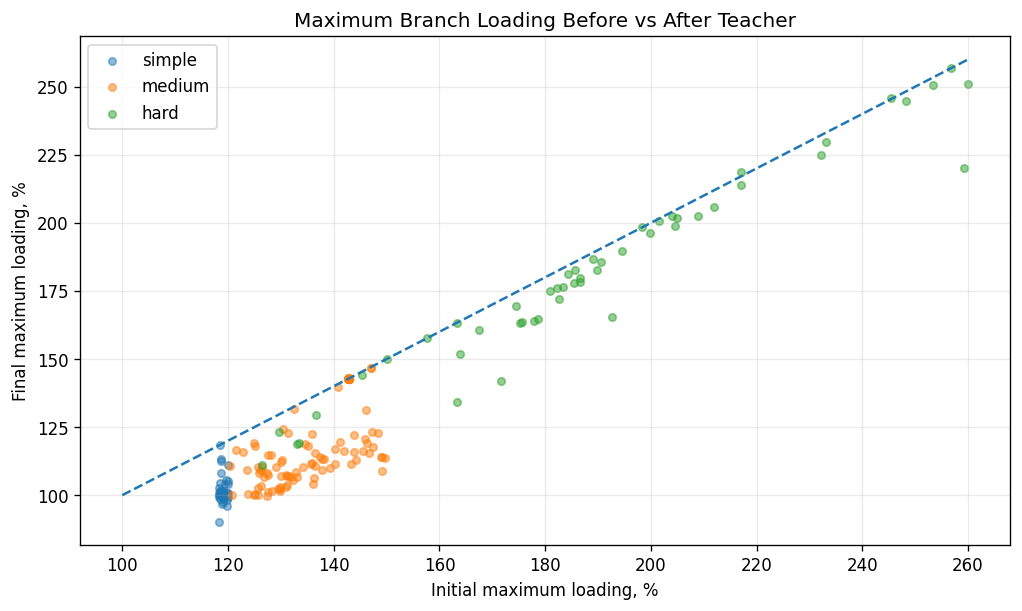

In [32]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = scenario[
        scenario["difficulty_class"] == difficulty
    ]

    ax.scatter(
        data["max_loading_percent"],
        data["final_max_loading_percent"],
        s=20,
        alpha=0.5,
        label=difficulty,
    )

limit = max(
    scenario["max_loading_percent"].max(),
    scenario["final_max_loading_percent"].max(),
)

ax.plot(
    [100, limit],
    [100, limit],
    linestyle="--",
)

ax.set_title("Maximum Branch Loading Before vs After Teacher")
ax.set_xlabel("Initial maximum loading, %")
ax.set_ylabel("Final maximum loading, %")
ax.legend()

plt.show()

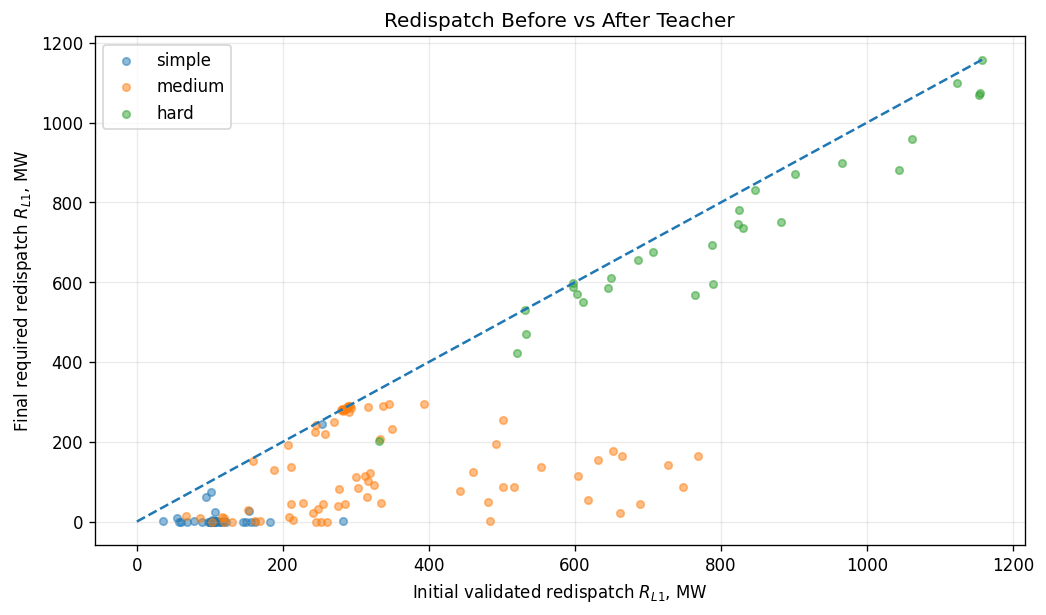

In [51]:
redispatch_compare = (
    examples
    .sort_values(["split", "difficulty_class", "scenario_id", "step"])
    .groupby(
        ["split", "difficulty_class", "scenario_id"],
        as_index=False,
    )
    .agg(
        initial_redispatch_validated=("initial_redispatch_validated", "first"),
        initial_redispatch_l1_mw=("initial_redispatch_l1_mw", "first"),

        teacher_outcome=("teacher_outcome", "first"),

        final_redispatch_validated=("redispatch_validated", "first"),
        final_redispatch_l1_mw=("redispatch_l1_mw", "first"),
    )
)

# Final required redispatch:
# solved topology -> 0 MW
# redispatch outcome -> validated final redispatch magnitude
# no validated terminal solution -> NaN
redispatch_compare["final_required_redispatch_l1_mw"] = np.where(
    redispatch_compare["teacher_outcome"].eq("solved"),
    0.0,
    np.where(
        redispatch_compare["final_redispatch_validated"].fillna(False),
        redispatch_compare["final_redispatch_l1_mw"],
        np.nan,
    ),
)

# Compare only physically validated initial redispatch values
plot_data = redispatch_compare[
    redispatch_compare["initial_redispatch_validated"].fillna(False)
    & redispatch_compare["initial_redispatch_l1_mw"].notna()
    & redispatch_compare["final_required_redispatch_l1_mw"].notna()
].copy()

fig, ax = plt.subplots()

for difficulty in classes:
    data = plot_data[
        plot_data["difficulty_class"] == difficulty
    ]

    ax.scatter(
        data["initial_redispatch_l1_mw"],
        data["final_required_redispatch_l1_mw"],
        s=20,
        alpha=0.5,
        label=difficulty,
    )

limit = max(
    plot_data["initial_redispatch_l1_mw"].max(),
    plot_data["final_required_redispatch_l1_mw"].max(),
)

ax.plot(
    [0, limit],
    [0, limit],
    linestyle="--",
)

ax.set_title("Redispatch Before vs After Teacher")
ax.set_xlabel(r"Initial validated redispatch $R_{L1}$, MW")
ax.set_ylabel(r"Final required redispatch $R_{L1}$, MW")
ax.legend()

plt.show()

In [54]:
redispatch_stats = redispatch_compare.copy()

# Absolute improvement:
# positive value = Teacher reduced required redispatch
redispatch_stats["redispatch_improvement_mw"] = (
    redispatch_stats["initial_redispatch_l1_mw"]
    - redispatch_stats["final_required_redispatch_l1_mw"]
)

# Relative improvement in %
redispatch_stats["redispatch_improvement_percent"] = np.where(
    redispatch_stats["initial_redispatch_l1_mw"] > 0,
    100.0
    * redispatch_stats["redispatch_improvement_mw"]
    / redispatch_stats["initial_redispatch_l1_mw"],
    np.nan,
)

# Physically comparable cases:
# initial redispatch validated and final required redispatch known
comparable = redispatch_stats[
    redispatch_stats["initial_redispatch_validated"].fillna(False)
    & redispatch_stats["initial_redispatch_l1_mw"].notna()
    & redispatch_stats["final_required_redispatch_l1_mw"].notna()
].copy()


def summarize_redispatch(group):
    return pd.Series(
        {
            "Scenarios": len(group),

            "Initial redispatch mean, MW":
                group["initial_redispatch_l1_mw"].mean(),

            "Final redispatch mean, MW":
                group["final_required_redispatch_l1_mw"].mean(),

            "Mean improvement, MW":
                group["redispatch_improvement_mw"].mean(),

            "Median improvement, MW":
                group["redispatch_improvement_mw"].median(),

            "Mean improvement, %":
                group["redispatch_improvement_percent"].mean(),

            "Median improvement, %":
                group["redispatch_improvement_percent"].median(),

            "Improved scenarios, %":
                100.0
                * (group["redispatch_improvement_mw"] > 0).mean(),

            "Unchanged scenarios, %":
                100.0
                * np.isclose(
                    group["redispatch_improvement_mw"],
                    0.0,
                    atol=1e-9,
                ).mean(),

            "Worse scenarios, %":
                100.0
                * (group["redispatch_improvement_mw"] < 0).mean(),

            "Final redispatch = 0, %":
                100.0
                * np.isclose(
                    group["final_required_redispatch_l1_mw"],
                    0.0,
                    atol=1e-9,
                ).mean(),
        }
    )


summary_by_class = pd.DataFrame(
    {
        difficulty: summarize_redispatch(
            comparable[
                comparable["difficulty_class"] == difficulty
            ]
        )
        for difficulty in classes
    }
).T

summary_total = summarize_redispatch(comparable).to_frame().T
summary_total.index = ["all"]

redispatch_summary = pd.concat(
    [summary_by_class, summary_total],
    axis=0,
)

redispatch_summary = redispatch_summary.round(2)

summary_total = summarize_redispatch(comparable).to_frame().T
summary_total.index = ["all"]

redispatch_summary = pd.concat(
    [summary_by_class, summary_total],
    axis=0,
)

redispatch_summary = redispatch_summary.round(2)

display(redispatch_summary)

,Scenarios,"Initial redispatch mean, MW","Final redispatch mean, MW","Mean improvement, MW","Median improvement, MW","Mean improvement, %","Median improvement, %","Improved scenarios, %","Unchanged scenarios, %","Worse scenarios, %","Final redispatch = 0, %"
simple,40.0,114.91,11.24,103.67,105.33,92.49,99.89,100.00,0.00,0.0,0.0
medium,77.0,334.15,131.75,202.40,180.41,57.65,75.14,93.51,6.49,0.0,0.0
hard,28.0,790.04,720.42,69.62,61.19,9.54,7.12,89.29,10.71,0.0,0.0
all,145.0,361.71,212.18,149.52,105.88,57.97,77.97,94.48,5.52,0.0,0.0


In [55]:
switch_steps = examples[
    examples["selected_branch_id"].notna()
].copy()

switch_steps["move"] = switch_steps["step"] + 1

delta_J_by_move = (
    switch_steps
    .groupby(["difficulty_class", "move"])
    .agg(
        mean_delta_J=("step_reward", "mean"),
        median_delta_J=("step_reward", "median"),
        scenarios=("scenario_id", "nunique"),
    )
    .reset_index()
)

display(delta_J_by_move.round(2))

,difficulty_class,move,mean_delta_J,median_delta_J,scenarios
0,hard,1,31.44,21.98,47
1,hard,2,33.54,28.12,33
2,hard,3,45.09,40.68,25
3,hard,4,29.96,20.16,21
4,hard,5,20.45,15.19,18
5,hard,6,27.73,15.82,13
6,medium,1,52.17,26.15,95
7,medium,2,62.30,49.83,83
8,medium,3,25.95,17.76,74
9,medium,4,16.13,12.38,56


In [56]:
coverage = (
    redispatch_stats
    .groupby("difficulty_class", sort=False)
    .agg(
        scenarios=("scenario_id", "size"),
        initial_redispatch_validated=(
            "initial_redispatch_validated",
            lambda x: int(x.fillna(False).sum()),
        ),
        final_solution_available=(
            "final_required_redispatch_l1_mw",
            lambda x: int(x.notna().sum()),
        ),
        solved_topology=(
            "teacher_outcome",
            lambda x: int((x == "solved").sum()),
        ),
        redispatch_outcome=(
            "teacher_outcome",
            lambda x: int((x == "redispatch").sum()),
        ),
        max_steps_reached=(
            "teacher_outcome",
            lambda x: int((x == "max_steps_reached").sum()),
        ),
    )
)

coverage["final_solution_rate, %"] = (
    100.0
    * coverage["final_solution_available"]
    / coverage["scenarios"]
)

display(coverage.round(2))

,scenarios,initial_redispatch_validated,final_solution_available,solved_topology,redispatch_outcome,max_steps_reached,"final_solution_rate, %"
difficulty_class,,,,,,,
hard,50,28,40,0,40,10,80.0
medium,100,77,100,0,100,0,100.0
simple,50,40,50,0,50,0,100.0


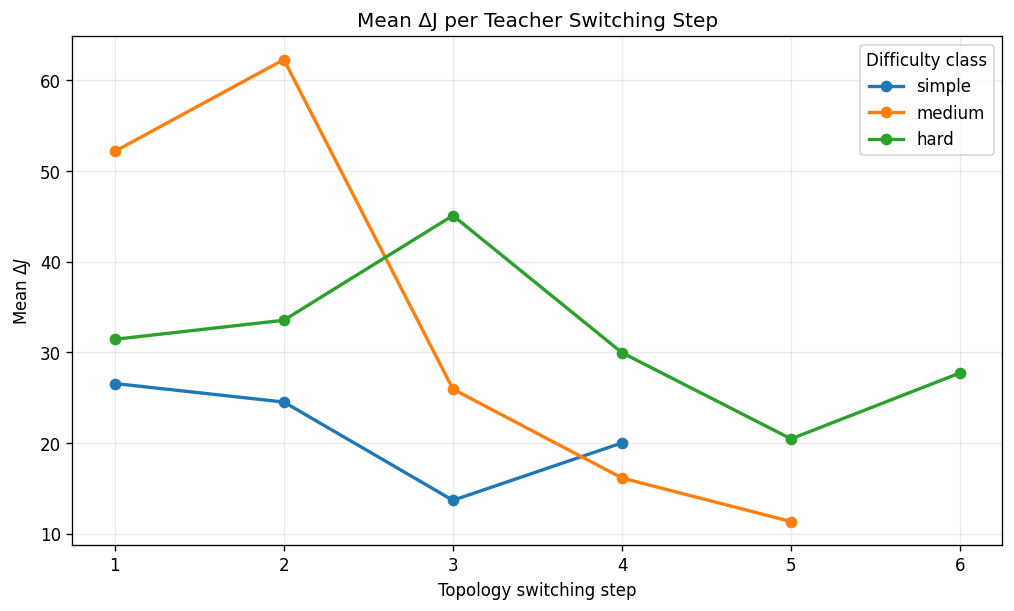

In [34]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = delta_J_by_move[
        delta_J_by_move["difficulty_class"] == difficulty
    ]

    ax.plot(
        data["move"],
        data["mean_delta_J"],
        marker="o",
        linewidth=2,
        label=difficulty,
    )


ax.set_title("Mean ΔJ per Teacher Switching Step")
ax.set_xlabel("Topology switching step")
ax.set_ylabel(r"Mean $\Delta  J$")
ax.set_xticks(sorted(delta_J_by_move["move"].unique()))
ax.legend(title="Difficulty class")

plt.show()

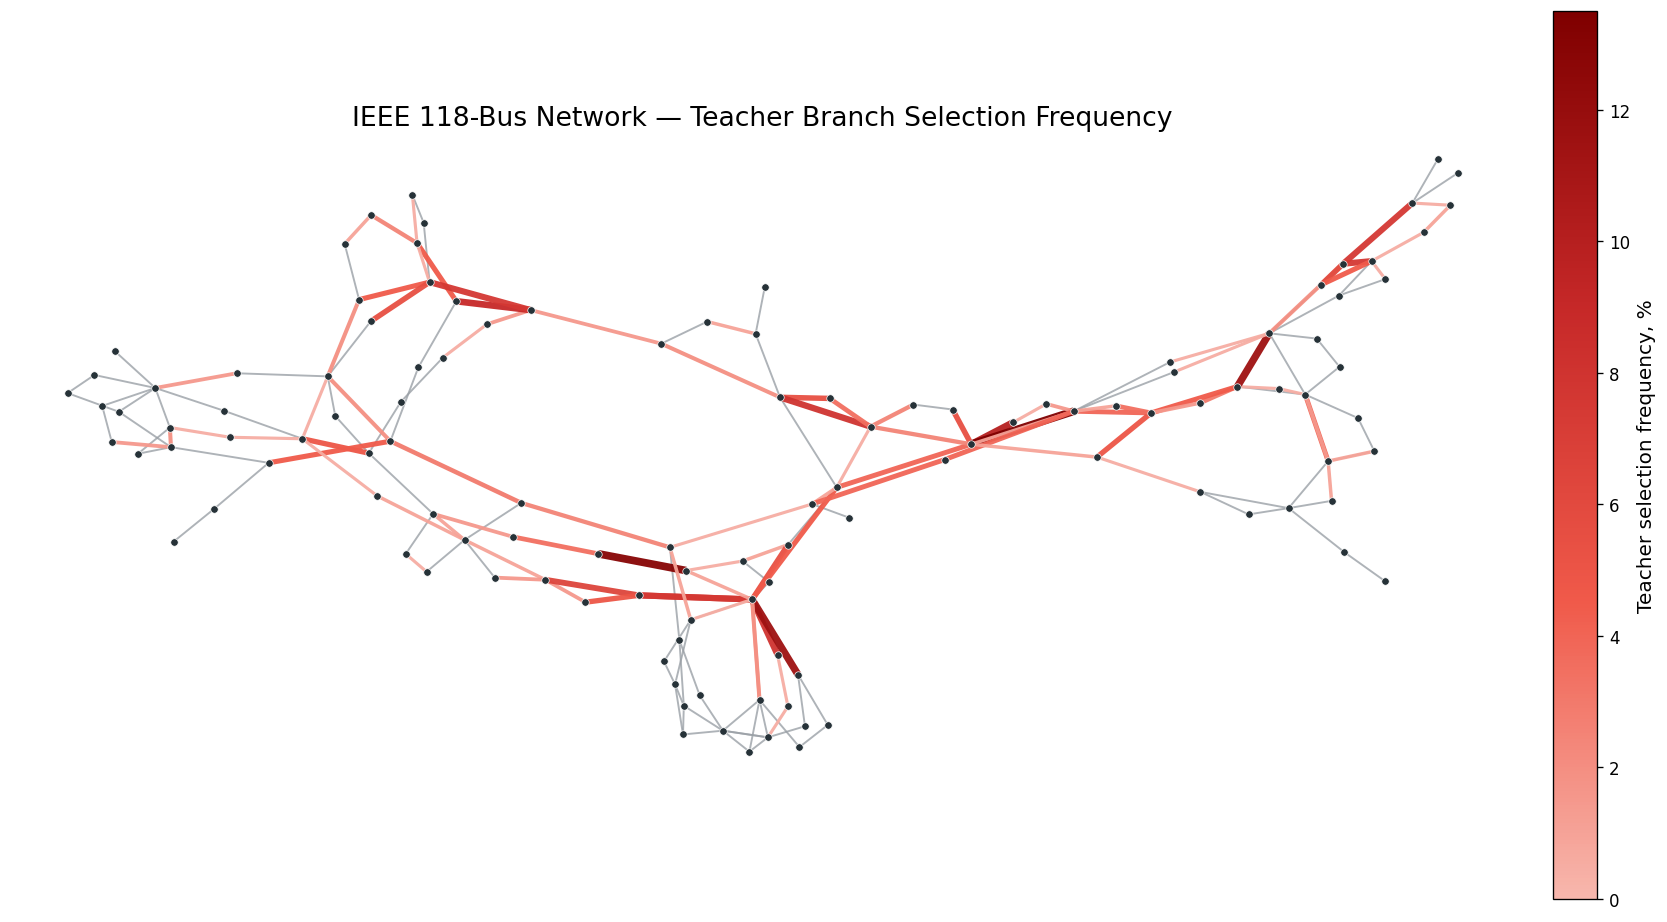

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np

state_path = next(
    (DATASET_DIR / "train" / "simple" / "states").glob("*.npz")
)

with np.load(state_path, allow_pickle=False) as data:
    bus_ids = data["bus_ids"].astype(int)
    branch_ids = data["branch_ids"].astype(int)
    edge_index = data["edge_index"].astype(int)

from_buses = bus_ids[edge_index[0]]
to_buses = bus_ids[edge_index[1]]

branch_topology = pd.DataFrame({
    "branch_id": branch_ids,
    "from_bus": from_buses,
    "to_bus": to_buses,
})

teacher_switches = examples[
    examples["selected_branch_id"].notna()
][
    [
        "split",
        "difficulty_class",
        "scenario_id",
        "selected_branch_id",
    ]
].copy()

teacher_switches["selected_branch_id"] = (
    teacher_switches["selected_branch_id"].astype(int)
)

# Count a branch only once per scenario
teacher_switches = teacher_switches.drop_duplicates(
    [
        "split",
        "difficulty_class",
        "scenario_id",
        "selected_branch_id",
    ]
)

total_scenarios = (
    examples[
        ["split", "difficulty_class", "scenario_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

teacher_frequency = (
    teacher_switches
    .groupby("selected_branch_id")
    .size()
    .rename("scenario_count")
    .reset_index()
)

teacher_frequency["teacher_frequency"] = (
    100.0
    * teacher_frequency["scenario_count"]
    / total_scenarios
)

edge_stats = branch_topology.merge(
    teacher_frequency,
    left_on="branch_id",
    right_on="selected_branch_id",
    how="left",
)

edge_stats["scenario_count"] = (
    edge_stats["scenario_count"]
    .fillna(0)
    .astype(int)
)

edge_stats["teacher_frequency"] = (
    edge_stats["teacher_frequency"]
    .fillna(0.0)
)

G = nx.Graph()

for row in edge_stats.itertuples():
    G.add_edge(row.from_bus, row.to_bus)

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.42,
    iterations=500,
)

zero_segments = []
teacher_segments = []
teacher_frequencies = []

for row in edge_stats.itertuples():
    segment = [
        pos[row.from_bus],
        pos[row.to_bus],
    ]

    if row.scenario_count == 0:
        zero_segments.append(segment)
    else:
        teacher_segments.append(segment)
        teacher_frequencies.append(row.teacher_frequency)

teacher_frequencies = np.asarray(teacher_frequencies)

vmax = (
    teacher_frequencies.max()
    if len(teacher_frequencies)
    else 1.0
)

norm = mpl.colors.Normalize(
    vmin=0,
    vmax=vmax,
)

cmap = LinearSegmentedColormap.from_list(
    "teacher_red",
    [
        "#f7b7ad",
        "#f05a4a",
        "#c62828",
        "#7f0000",
    ],
)

fig, ax = plt.subplots(figsize=(14, 8))

base_edges = LineCollection(
    zero_segments,
    colors="#9aa0a6",
    linewidths=1.15,
    alpha=0.8,
    zorder=1,
)

ax.add_collection(base_edges)

if len(teacher_segments):
    widths = (
        1.5
        + 3.2
        * np.power(
            teacher_frequencies / vmax,
            0.65,
        )
    )

    teacher_edges = LineCollection(
        teacher_segments,
        cmap=cmap,
        norm=norm,
        linewidths=widths,
        alpha=0.95,
        zorder=2,
    )

    teacher_edges.set_array(
        teacher_frequencies
    )

    ax.add_collection(
        teacher_edges
    )

nodes = np.array(
    [pos[node] for node in G.nodes()]
)

ax.scatter(
    nodes[:, 0],
    nodes[:, 1],
    s=20,
    c="#263238",
    edgecolors="white",
    linewidths=0.4,
    zorder=3,
)

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.028,
    pad=0.025,
)

cbar.set_label(
    "Teacher selection frequency, %",
    fontsize=12,
)

ax.set_title(
    "IEEE 118-Bus Network — Teacher Branch Selection Frequency",
    fontsize=16,
)

ax.set_aspect("equal")
ax.margins(0.04)
ax.axis("off")

plt.tight_layout()
plt.show()

## 15. Retained physical improvement

In [36]:
retained_stats = (
    scenario
    .groupby("difficulty_class")["retained_improvement_percent"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(retained_stats)

,count,mean,std,min,5%,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,,
simple,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medium,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hard,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


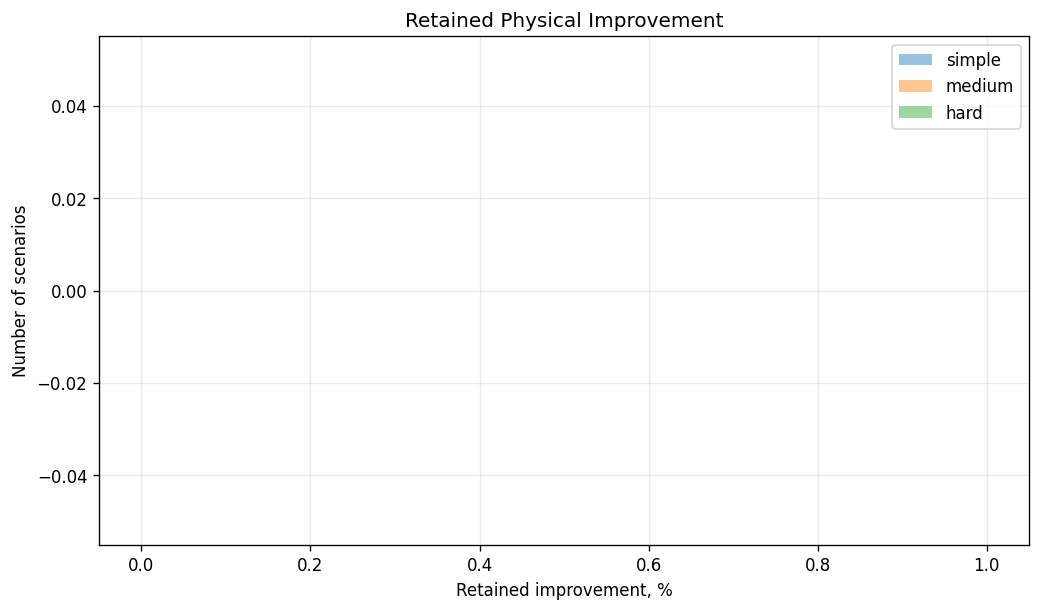

In [37]:
fig, ax = plt.subplots()

for difficulty in classes:
    values = scenario.loc[
        scenario["difficulty_class"] == difficulty,
        "retained_improvement_percent",
    ].dropna()
    ax.hist(values, bins=40, alpha=0.45, label=difficulty)

ax.set_title("Retained Physical Improvement")
ax.set_xlabel("Retained improvement, %")
ax.set_ylabel("Number of scenarios")
ax.legend()
plt.show()

## 16. Redispatch terminal candidates

In [38]:
terminal_candidate_stats = (
    scenario
    .groupby("difficulty_class")["terminal_candidate_count"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(terminal_candidate_stats)

,count,mean,std,min,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,
simple,50.0,21.84,3.705264,5.0,21.00,23.0,24.0,25.0,25.0
medium,100.0,25.24,5.850183,3.0,23.00,27.0,30.0,31.0,31.0
hard,50.0,20.90,13.946326,0.0,4.75,25.0,33.0,37.0,37.0


,any_terminal_candidate,terminal_selection_applied,redispatch_validated
difficulty_class,,,
simple,100.0,100.0,100.0
medium,100.0,100.0,100.0
hard,80.0,80.0,80.0


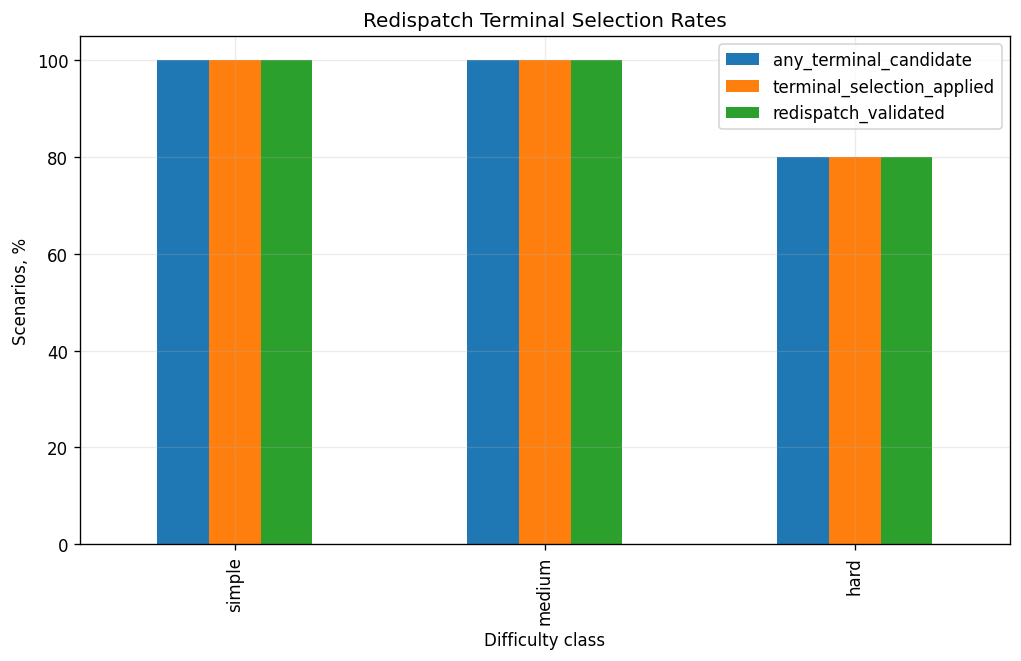

In [39]:
terminal_rates = (
    100.0
    * scenario
    .groupby("difficulty_class")
    .agg(
        any_terminal_candidate=("terminal_candidate_count", lambda s: (s > 0).mean()),
        terminal_selection_applied=("terminal_selection_applied", "mean"),
        redispatch_validated=("redispatch_validated", lambda s: s.fillna(False).mean()),
    )
    .reindex(classes)
)

display(terminal_rates)

fig, ax = plt.subplots()
terminal_rates.plot(kind="bar", ax=ax)
ax.set_title("Redispatch Terminal Selection Rates")
ax.set_xlabel("Difficulty class")
ax.set_ylabel("Scenarios, %")
ax.legend()
plt.show()

## 17. Redispatch Pareto front size

In [40]:
redispatch_pareto_stats = (
    scenario
    .groupby("difficulty_class")["redispatch_pareto_size"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(redispatch_pareto_stats)

,count,mean,std,min,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,
simple,50.0,3.74,1.006307,2.0,3.0,4.0,5.0,5.0,5.0
medium,100.0,4.52,1.226640,1.0,4.0,5.0,5.0,6.0,6.0
hard,50.0,2.40,1.653691,0.0,2.0,2.0,4.0,5.0,6.0


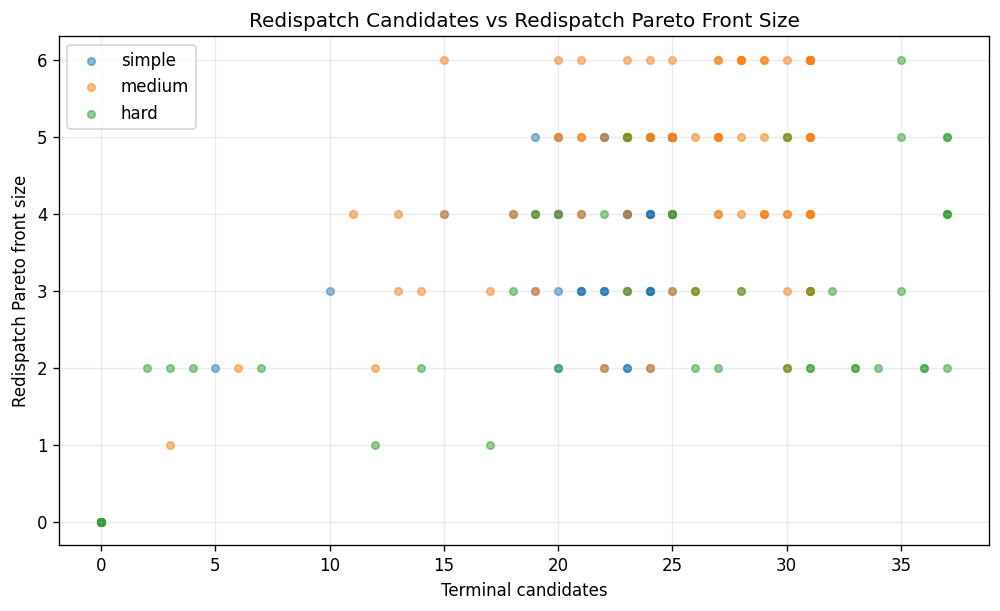

In [41]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = scenario[scenario["difficulty_class"] == difficulty]
    ax.scatter(
        data["terminal_candidate_count"],
        data["redispatch_pareto_size"],
        s=20,
        alpha=0.5,
        label=difficulty,
    )

ax.set_title("Redispatch Candidates vs Redispatch Pareto Front Size")
ax.set_xlabel("Terminal candidates")
ax.set_ylabel("Redispatch Pareto front size")
ax.legend()
plt.show()

## 18. Validated redispatch magnitude

In [42]:
validated = scenario[
    scenario["redispatch_validated"].fillna(False)
    & scenario["redispatch_l1_mw"].notna()
].copy()

redispatch_stats = (
    validated
    .groupby("difficulty_class")["redispatch_l1_mw"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .reindex(classes)
)

display(redispatch_stats)

,count,mean,std,min,5%,25%,50%,75%,95%,max
difficulty_class,,,,,,,,,,
simple,50.0,9.023400,36.775996,0.043546,0.051833,0.071063,0.114689,0.305771,45.543843,244.238386
medium,100.0,118.711665,103.125251,0.041228,0.097931,21.604296,88.802743,205.490133,288.831400,295.604960
hard,40.0,661.596334,224.961651,203.042633,374.500529,528.162753,604.464536,793.135913,1075.174912,1157.805450


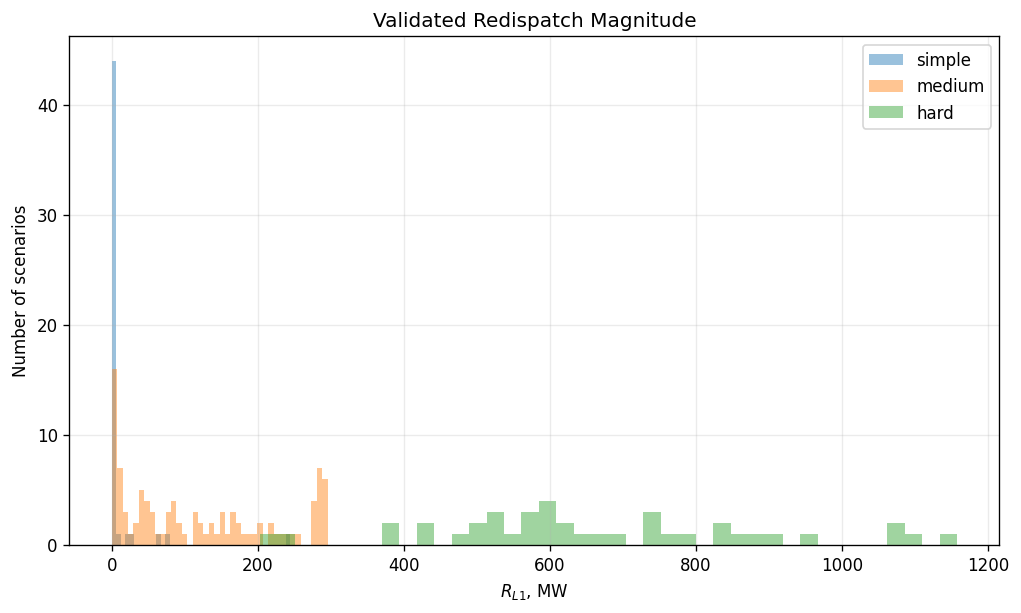

In [43]:
fig, ax = plt.subplots()

for difficulty in classes:
    values = validated.loc[
        validated["difficulty_class"] == difficulty,
        "redispatch_l1_mw",
    ]
    ax.hist(values, bins=40, alpha=0.45, label=difficulty)

ax.set_title("Validated Redispatch Magnitude")
ax.set_xlabel(r"$R_{L1}$, MW")
ax.set_ylabel("Number of scenarios")
ax.legend()
plt.show()

In [44]:
redispatch_components = (
    validated
    .groupby("difficulty_class")
    .agg(
        mean_l1_mw=("redispatch_l1_mw", "mean"),
        median_l1_mw=("redispatch_l1_mw", "median"),
        mean_up_mw=("redispatch_up_mw", "mean"),
        mean_down_mw=("redispatch_down_mw", "mean"),
        mean_max_generator_delta_mw=("redispatch_max_generator_delta_mw", "mean"),
    )
    .reindex(classes)
)

display(redispatch_components)

,mean_l1_mw,median_l1_mw,mean_up_mw,mean_down_mw,mean_max_generator_delta_mw
difficulty_class,,,,,
simple,9.023400,0.114689,5.384144,3.639256,2.482047
medium,118.711665,88.802743,63.324876,55.386788,47.055261
hard,661.596334,604.464536,307.989293,353.607040,289.916128


## 19. Redispatch vs topology switching effort

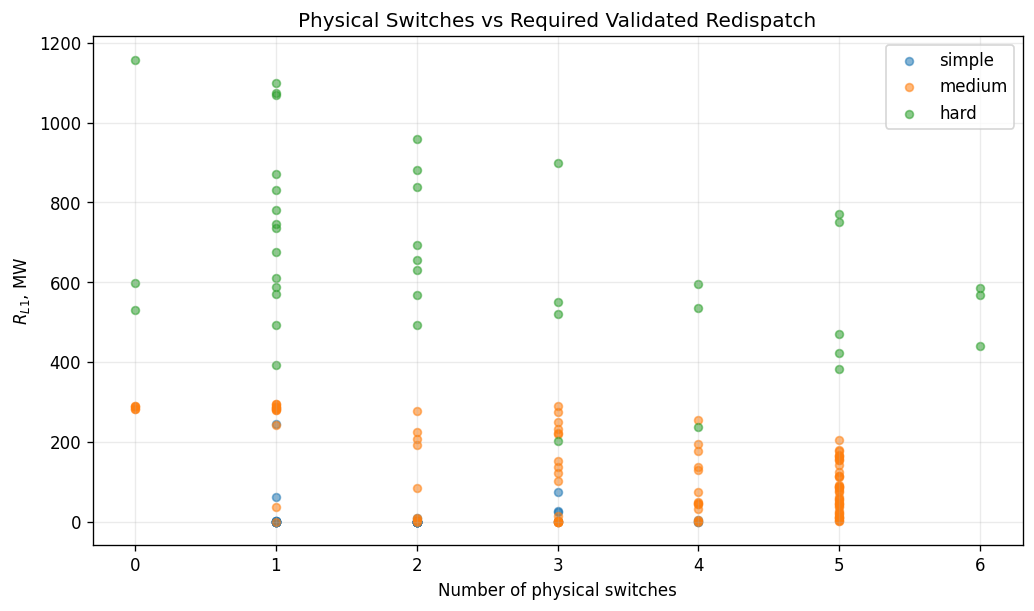

In [45]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = validated[validated["difficulty_class"] == difficulty]
    ax.scatter(
        data["physical_switches"],
        data["redispatch_l1_mw"],
        s=22,
        alpha=0.55,
        label=difficulty,
    )

ax.set_title("Physical Switches vs Required Validated Redispatch")
ax.set_xlabel("Number of physical switches")
ax.set_ylabel(r"$R_{L1}$, MW")
ax.legend()
plt.show()

## 20. Final J vs required redispatch

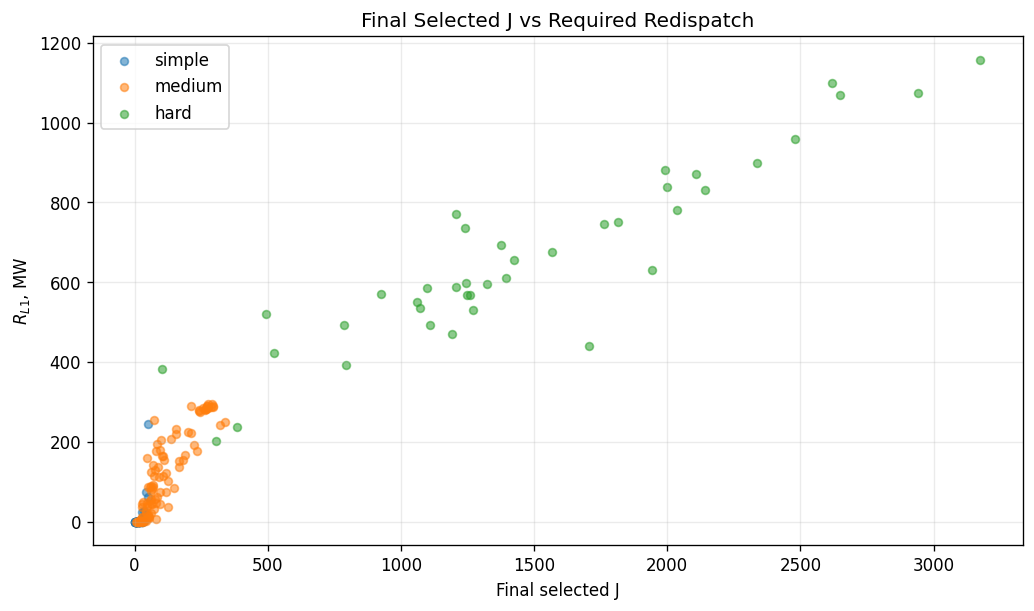

In [46]:
fig, ax = plt.subplots()

for difficulty in classes:
    data = validated[validated["difficulty_class"] == difficulty]
    ax.scatter(
        data["teacher_selected_J"],
        data["redispatch_l1_mw"],
        s=22,
        alpha=0.55,
        label=difficulty,
    )

ax.set_title("Final Selected J vs Required Redispatch")
ax.set_xlabel("Final selected J")
ax.set_ylabel(r"$R_{L1}$, MW")
ax.legend()
plt.show()

## 21. Pareto-stage summary by class

In [47]:
pareto_summary = (
    scenario
    .groupby("difficulty_class")
    .agg(
        scenarios=("scenario_id", "count"),
        mean_topology_pareto_size=("topology_pareto_size", "mean"),
        median_topology_pareto_size=("topology_pareto_size", "median"),
        mean_terminal_candidates=("terminal_candidate_count", "mean"),
        mean_redispatch_pareto_size=("redispatch_pareto_size", "mean"),
        median_redispatch_pareto_size=("redispatch_pareto_size", "median"),
        mean_best_J=("teacher_best_J", "mean"),
        mean_final_J=("teacher_selected_J", "mean"),
        mean_J_gap=("J_gap_to_best", "mean"),
        mean_switches=("physical_switches", "mean"),
        redispatch_selection_rate=("terminal_selection_applied", "mean"),
    )
    .reindex(classes)
)

pareto_summary["redispatch_selection_rate"] *= 100.0

display(pareto_summary)

,scenarios,mean_topology_pareto_size,median_topology_pareto_size,mean_terminal_candidates,mean_redispatch_pareto_size,median_redispatch_pareto_size,mean_best_J,mean_final_J,mean_J_gap,mean_switches,redispatch_selection_rate
difficulty_class,,,,,,,,,,,
simple,50,NaN,NaN,21.84,3.74,4.0,NaN,15.590710,NaN,1.84,100.0
medium,100,NaN,NaN,25.24,4.52,5.0,NaN,114.813703,NaN,3.50,100.0
hard,50,NaN,NaN,20.90,2.40,2.0,NaN,1302.164621,NaN,3.14,80.0


## 22. Train vs validation Pareto comparison

In [48]:
split_pareto = (
    scenario
    .groupby("split")
    .agg(
        scenarios=("scenario_id", "count"),
        mean_topology_pareto_size=("topology_pareto_size", "mean"),
        mean_terminal_candidates=("terminal_candidate_count", "mean"),
        mean_redispatch_pareto_size=("redispatch_pareto_size", "mean"),
        mean_best_J=("teacher_best_J", "mean"),
        mean_final_J=("teacher_selected_J", "mean"),
        mean_switches=("physical_switches", "mean"),
        redispatch_selection_rate=("terminal_selection_applied", "mean"),
    )
    .reindex(splits)
)

split_pareto["redispatch_selection_rate"] *= 100.0

display(split_pareto)

,scenarios,mean_topology_pareto_size,mean_terminal_candidates,mean_redispatch_pareto_size,mean_best_J,mean_final_J,mean_switches,redispatch_selection_rate
split,,,,,,,,
train,100,NaN,24.65,3.95,NaN,442.713814,2.89,98.0
val,100,NaN,21.96,3.64,NaN,330.977554,3.10,92.0


## 23. Most frequently selected branches

In [49]:
branch_actions = examples[
    examples["selected_branch_id"].notna()
][
    [
        "split",
        "difficulty_class",
        "scenario_id",
        "selected_branch_id",
    ]
].copy()

branch_actions["selected_branch_id"] = branch_actions["selected_branch_id"].astype(int)

branch_frequency = (
    branch_actions
    .groupby(["difficulty_class", "selected_branch_id"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(
        ["difficulty_class", "count"],
        ascending=[True, False],
    )
)

top_branches_by_class = (
    branch_frequency
    .groupby("difficulty_class", group_keys=False)
    .head(15)
)

display(top_branches_by_class)

,difficulty_class,selected_branch_id,count
4,hard,30,16
50,hard,178,8
11,hard,41,7
18,hard,56,7
25,hard,64,7
26,hard,69,7
27,hard,70,7
22,hard,60,6
19,hard,57,5
1,hard,10,4


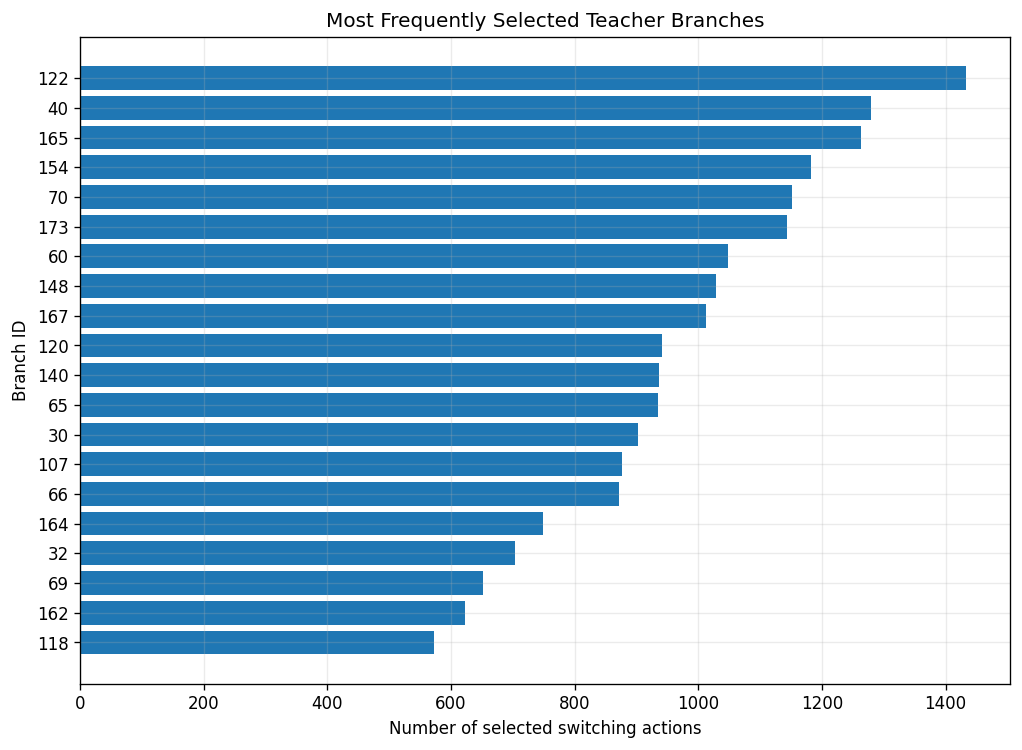

In [38]:
overall_branch_frequency = (
    branch_actions["selected_branch_id"]
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    overall_branch_frequency.index.astype(str),
    overall_branch_frequency.values,
)
ax.set_title("Most Frequently Selected Teacher Branches")
ax.set_xlabel("Number of selected switching actions")
ax.set_ylabel("Branch ID")
plt.show()

## 24. Detailed scenario table

In [39]:
detailed_columns = [
    "split",
    "difficulty_class",
    "scenario_id",

    "max_loading_percent",
    "num_overloaded_branches",
    "num_hard_overloaded_branches",
    "seriousness_score",

    "initial_J",
    "teacher_best_J",
    "teacher_selected_J",
    "J_gap_to_best",
    "J_improvement",
    "retained_improvement_percent",

    "topology_pareto_size",
    "terminal_candidate_count",
    "redispatch_pareto_size",
    "terminal_selection_applied",

    "physical_switches",
    "sequence",

    "redispatch_validated",
    "redispatch_l1_mw",
    "redispatch_max_generator_delta_mw",

    "solved",
    "termination_reason",
]

detailed = scenario[detailed_columns].sort_values(
    ["difficulty_class", "split", "seriousness_score"],
    ascending=[True, True, False],
)

display(detailed)

,split,difficulty_class,scenario_id,max_loading_percent,num_overloaded_branches,num_hard_overloaded_branches,seriousness_score,initial_J,teacher_best_J,teacher_selected_J,...,terminal_candidate_count,redispatch_pareto_size,terminal_selection_applied,physical_switches,sequence,redispatch_validated,redispatch_l1_mw,redispatch_max_generator_delta_mw,solved,termination_reason
7404,train,hard,9628,174.902461,10,6,14896.632032,1911.563048,1798.667716,1798.667716,...,0,0,False,6,70 → 120 → 184 → 74 → 38 → 69,False,NaN,NaN,False,max_steps_reached
9177,train,hard,11924,175.216402,9,6,14697.439315,1843.697644,1701.174500,1701.174500,...,0,0,False,6,69 → 70 → 75 → 74 → 38 → 178,False,NaN,NaN,False,max_steps_reached
9102,train,hard,11819,174.613291,7,6,14294.272001,1719.806224,1605.213281,1605.213281,...,0,0,False,6,69 → 70 → 74 → 75 → 49 → 102,False,NaN,NaN,False,max_steps_reached
7421,train,hard,9654,157.023153,11,5,13006.872790,1385.358102,1235.083649,1235.083649,...,0,0,False,6,125 → 184 → 38 → 70 → 69 → 74,False,NaN,NaN,False,max_steps_reached
7888,train,hard,10251,156.153544,10,5,12802.522237,1400.437133,1297.210603,1297.210603,...,0,0,False,6,38 → 184 → 70 → 120 → 49 → 45,False,NaN,NaN,False,max_steps_reached
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9335,val,simple,491,114.774695,1,0,793.873477,45.549406,6.000013,18.232008,...,3,3,True,1,154 → STOP,True,0.118677,0.014360,False,redispatch_validated
9345,val,simple,535,114.770845,1,0,793.854510,43.541831,4.000001,4.000001,...,1,1,True,1,154 → STOP,True,0.120873,0.009770,False,redispatch_validated
9445,val,simple,1039,114.769609,1,0,793.848043,46.539229,7.000014,7.000014,...,2,2,True,2,149 → 155 → STOP,True,0.068016,0.006348,False,redispatch_validated
9584,val,simple,1697,114.749622,1,0,793.748108,42.499244,9.371251,10.593032,...,5,5,True,3,49 → 46 → 30 → STOP,True,0.529453,0.055892,False,redispatch_validated


## 25. Largest final-J gap to topology optimum

In [40]:
largest_J_gap = (
    scenario
    .sort_values(
        ["difficulty_class", "J_gap_to_best"],
        ascending=[True, False],
    )
    .groupby("difficulty_class", group_keys=False)
    .head(15)[
        [
            "split",
            "scenario_id",
            "difficulty_class",
            "teacher_best_J",
            "teacher_selected_J",
            "J_gap_to_best",
            "topology_pareto_size",
            "terminal_candidate_count",
            "redispatch_pareto_size",
            "physical_switches",
            "redispatch_l1_mw",
            "sequence",
        ]
    ]
)

display(largest_J_gap)

,split,scenario_id,difficulty_class,teacher_best_J,teacher_selected_J,J_gap_to_best,topology_pareto_size,terminal_candidate_count,redispatch_pareto_size,physical_switches,redispatch_l1_mw,sequence
6786,train,8848,hard,71.057606,183.804001,112.746395,7,1,1,2,997.345241,64 → 56 → STOP
11103,val,9876,hard,68.071137,175.586503,107.515366,7,5,1,1,88.966544,122 → STOP
11531,val,11997,hard,117.216568,223.006961,105.790393,7,4,1,2,123.423586,107 → 122 → STOP
7753,train,10085,hard,46.310585,149.060486,102.749901,7,1,1,1,68.051910,57 → STOP
7042,train,9181,hard,186.732784,268.364543,81.631760,7,1,1,3,305.731300,173 → 122 → 167 → STOP
8298,train,10779,hard,207.726116,287.264871,79.538755,7,2,1,1,248.074469,56 → STOP
8997,train,11683,hard,79.898412,157.695200,77.796788,7,4,1,1,138.016033,122 → STOP
7784,train,10121,hard,36.535572,112.015842,75.480270,7,2,1,4,36.745614,30 → 65 → 66 → 95 → STOP
8420,train,10936,hard,4.414696,78.963825,74.549129,7,2,1,3,48.249131,122 → 148 → 124 → STOP
7906,train,10275,hard,17.452518,91.896442,74.443924,7,1,1,3,51.148205,30 → 60 → 95 → STOP


## 26. Largest validated redispatch by class

In [43]:
largest_redispatch = (
    validated
    .sort_values(
        ["difficulty_class", "redispatch_l1_mw"],
        ascending=[True, False],
    )
    .groupby("difficulty_class", group_keys=False)
    .head(15)[
        [
            "split",
            "scenario_id",
            "difficulty_class",
            "teacher_selected_J",
            "physical_switches",
            "redispatch_l1_mw",
            "redispatch_up_mw",
            "redispatch_down_mw",
            "redispatch_max_generator_delta_mw",
            "sequence",
        ]
    ]
)

display(largest_redispatch)

,split,scenario_id,difficulty_class,teacher_selected_J,physical_switches,redispatch_l1_mw,redispatch_up_mw,redispatch_down_mw,redispatch_max_generator_delta_mw,sequence
6786,train,8848,hard,183.804001,2,997.345241,493.417457,503.927783,389.856991,64 → 56 → STOP
10980,val,9209,hard,57.837614,5,783.022354,403.400757,379.621597,379.621581,122 → 127 → 123 → 121 → 116 → STOP
8731,train,11340,hard,173.667069,5,706.090045,361.745726,344.344319,214.300490,122 → 127 → 123 → 124 → 53 → STOP
11062,val,9698,hard,71.013657,5,693.907046,348.064382,345.842663,305.350409,127 → 122 → 123 → 124 → 30 → STOP
11349,val,11093,hard,57.595353,4,618.409233,311.403877,307.005356,303.293142,122 → 127 → 123 → 121 → STOP
10904,val,8830,hard,217.792677,5,522.603924,259.303498,263.300426,127.506444,55 → 56 → 40 → 32 → 25 → STOP
7948,train,10330,hard,163.548053,4,514.142329,264.879595,249.262734,144.471492,29 → 101 → 126 → 122 → STOP
8771,train,11396,hard,201.388874,2,454.239241,229.840007,224.399234,130.681554,25 → 57 → STOP
7038,train,9174,hard,173.035236,4,440.170415,218.268835,221.901580,161.938057,109 → 126 → 40 → 120 → STOP
8372,train,10880,hard,154.316198,5,400.138786,168.291399,231.847386,115.642906,56 → 95 → 55 → 67 → 184 → STOP


## 27. Key indicators

In [42]:
key_indicators = pd.DataFrame({
    "Indicator": [
        "Teacher scenarios",
        "Saved state examples",
        "Mean physical switches",
        "Median physical switches",
        "Zero-switch scenarios, %",
        "Solved scenarios, %",
        "Redispatch-validated scenarios, %",

        "Mean initial J",
        "Mean best topology J",
        "Mean final selected J",
        "Mean J improvement",
        "Mean retained physical improvement, %",

        "Mean topology Pareto front size",
        "Maximum topology Pareto front size",
        "Mean terminal candidate count",
        "Mean redispatch Pareto front size",
        "Maximum redispatch Pareto front size",
        "Terminal redispatch selection applied, %",

        "Median validated redispatch, MW",
        "Mean validated redispatch, MW",
        "Maximum validated redispatch, MW",
    ],
    "Value": [
        len(scenario),
        len(examples),
        scenario["physical_switches"].mean(),
        scenario["physical_switches"].median(),
        100.0 * scenario["zero_switch"].mean(),
        100.0 * scenario["solved"].mean(),
        100.0 * scenario["redispatch_validated"].fillna(False).mean(),

        scenario["initial_J"].mean(),
        scenario["teacher_best_J"].mean(),
        scenario["teacher_selected_J"].mean(),
        scenario["J_improvement"].mean(),
        scenario["retained_improvement_percent"].mean(),

        scenario["topology_pareto_size"].mean(),
        scenario["topology_pareto_size"].max(),
        scenario["terminal_candidate_count"].mean(),
        scenario["redispatch_pareto_size"].mean(),
        scenario["redispatch_pareto_size"].max(),
        100.0 * scenario["terminal_selection_applied"].mean(),

        validated["redispatch_l1_mw"].median(),
        validated["redispatch_l1_mw"].mean(),
        validated["redispatch_l1_mw"].max(),
    ],
})

display(key_indicators)

,Indicator,Value
0,Teacher scenarios,11534.000000
1,Saved state examples,49000.000000
2,Mean physical switches,3.478152
3,Median physical switches,3.000000
4,"Zero-switch scenarios, %",0.442171
5,"Solved scenarios, %",0.112710
6,"Redispatch-validated scenarios, %",61.895266
7,Mean initial J,364.413289
8,Mean best topology J,231.412627
9,Mean final selected J,237.579919


## 28. Persisted Pareto information

The current teacher dataset stores scenario-level selection provenance:

- best topology J found;
- final selected J;
- retained physical improvement;
- topology Pareto front size;
- terminal redispatch candidate count;
- redispatch Pareto front size;
- whether redispatch-aware terminal selection was applied;
- validated redispatch diagnostics.

It does not persist every individual Pareto point, so this notebook analyzes the complete
Pareto information stored in the generated dataset without re-running Beam Search.